<a href="https://colab.research.google.com/github/yuvraj-013/DA_Projects/blob/main/loan_approval_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval Analysis

In [ ]:
import pandas as pd
df= pd.read_csv('/content/loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,lo,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [ ]:
df.columns = df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

# Approval/Rejection ratio by Education


* same for both Graduate and Non-Graduate




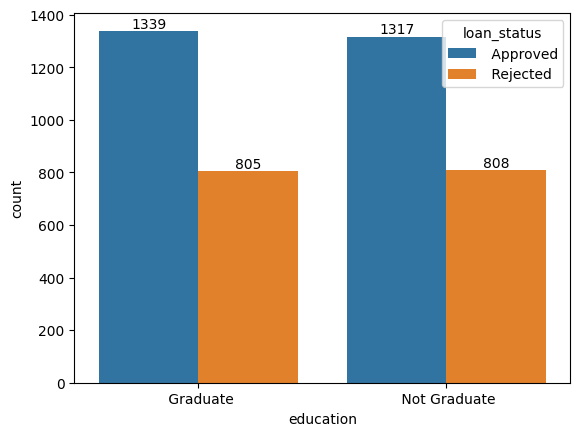

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
cp = sns.countplot(data = df, x='education', hue='loan_status')
for bar in cp.containers:
  plt.bar_label(bar)

# Loan Status by CIBIL score

*   High CIBIL score has more acceptance
*   Low CIBIL score has lower chances



Text(0.5, 1.0, 'Cibil score vs loan status')

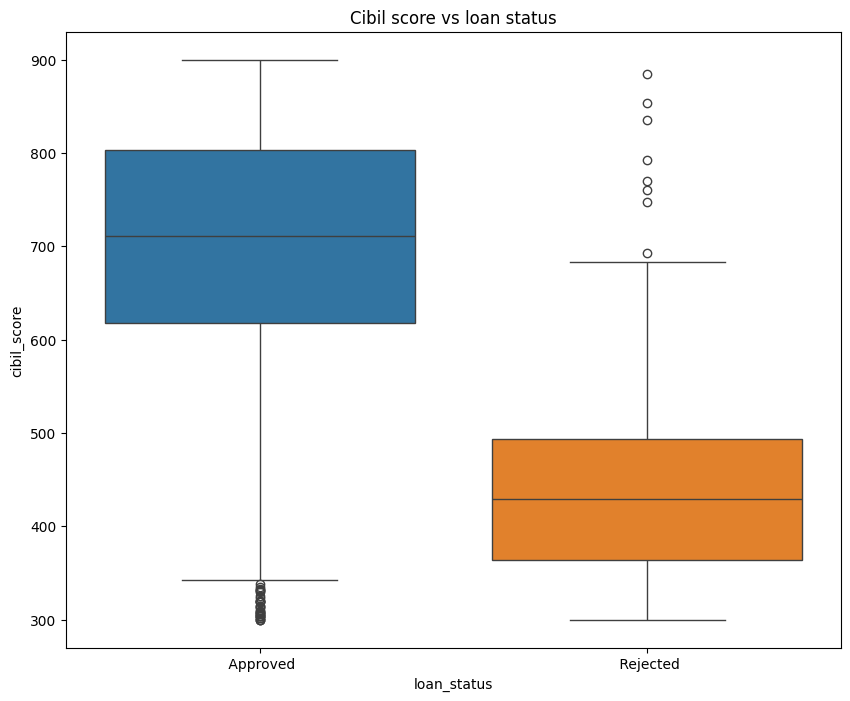

In [ ]:
df_cibil_status = df[['cibil_score', 'loan_status']]
plt.figure(figsize=(10,8))
bp =sns.boxplot(data = df_cibil_status, x='loan_status', y='cibil_score', hue='loan_status')
plt.title('Cibil score vs loan status')

`Some outliers are also present in **Approved** section having very low CIBIL score, which needs futher Analysis `

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   object
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(9), object(4)
memory usage: 433.7+ KB


Filter out the data of People having low CIBIL score and loan status is approved

In [ ]:
df_lowCIBIL = df[df['cibil_score']<400]
df_lowCIBIL = df_lowCIBIL[df_lowCIBIL['loan_status']==' Approved']

In [ ]:
df_lowCIBIL

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
71,72,5,Graduate,Yes,5300000,18600000,4,386,2700000,9700000,11900000,4200000,Approved
95,96,5,Graduate,No,300000,1100000,2,300,100000,500000,700000,400000,Approved
152,153,1,Graduate,Yes,6500000,20600000,2,306,15900000,1900000,18100000,3200000,Approved
169,170,0,Not Graduate,Yes,4800000,17500000,2,371,11700000,6800000,18700000,3500000,Approved
260,261,4,Not Graduate,No,2700000,8100000,4,325,5000000,800000,9900000,3400000,Approved
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,4076,4,Not Graduate,Yes,2600000,8500000,4,392,5500000,100000,8800000,2900000,Approved
4081,4082,2,Not Graduate,Yes,4400000,16800000,4,307,12800000,7200000,9700000,5800000,Approved
4139,4140,3,Graduate,No,5600000,20300000,4,330,16100000,5100000,15300000,4200000,Approved
4161,4162,5,Not Graduate,No,1100000,4000000,2,362,1800000,1300000,3500000,1100000,Approved


In [ ]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

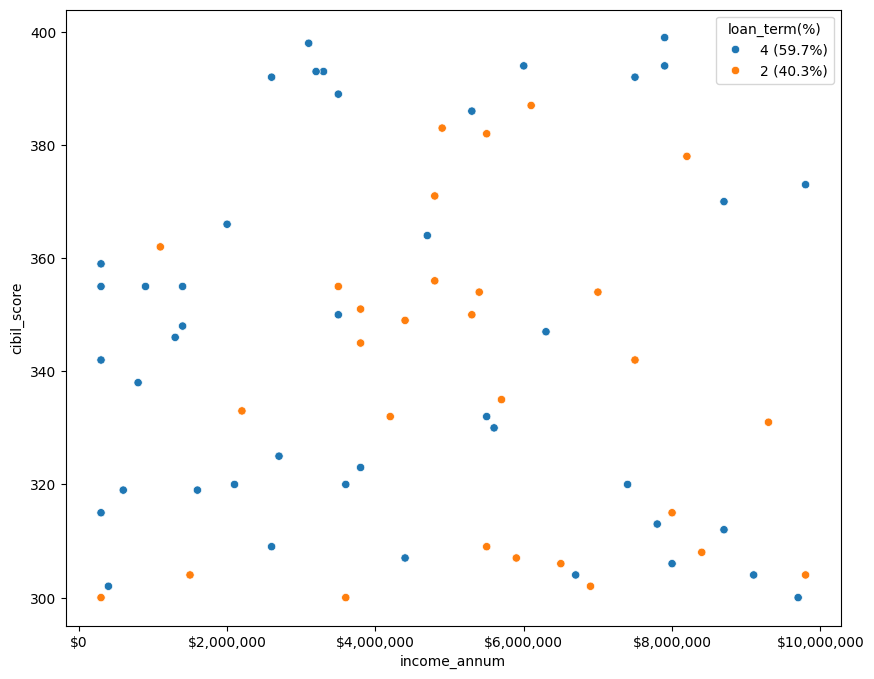

In [ ]:
#df_lowCIBIL.describe()
import matplotlib.ticker as mtick
plt.figure(figsize=(10,8))
counts = df_lowCIBIL['loan_term'].value_counts(normalize=True) * 100
sp = sns.scatterplot(data=df_lowCIBIL, x='income_annum', y='cibil_score', hue='loan_term')
fmt = '$' + '{x:,.0f}'
tick = mtick.StrMethodFormatter(fmt)
sp.xaxis.set_major_formatter(tick)


new_labels = []
for text_obj in sp.get_legend().get_texts():
    category_name = text_obj.get_text()

    # Check if the label exists in our counts (skips legend titles)
    if category_name in counts.index:
        percentage = counts[category_name]
        new_labels.append(f"{category_name} ({percentage:.1f}%)")
    else:
        new_labels.append(category_name)

# 5. Apply the new labels back to the legend
sp.legend(handles=sp.get_legend().legend_handles, labels=new_labels, title="loan_term(%)")

plt.show()

Analysis : All Low CIBIL score loans were approved for Short loan term for 2-4 months only

# Now analyzed why some outliers having  high CIBIL score were rejected for loan.

In [ ]:
df_highCIBIL = df[df['cibil_score']>700]
df_highCIBIL = df_highCIBIL[df_highCIBIL['loan_status']==' Rejected']

In [ ]:
df_highCIBIL

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
236,237,3,Graduate,Yes,900000,3500000,4,770,700000,0,2000000,600000,Rejected
559,560,2,Graduate,Yes,200000,500000,6,885,-100000,0,300000,200000,Rejected
911,912,0,Graduate,Yes,1300000,4800000,4,835,500000,100000,3300000,800000,Rejected
1446,1447,1,Graduate,No,300000,1200000,18,747,100000,0,700000,200000,Rejected
3213,3214,1,Not Graduate,Yes,4300000,16300000,14,792,400000,400000,10200000,4000000,Rejected
3527,3528,0,Graduate,No,1800000,6900000,10,853,900000,400000,3700000,1700000,Rejected
4099,4100,3,Graduate,No,8700000,31100000,16,760,400000,1800000,19300000,4800000,Rejected


In [ ]:
df.columns.str.strip()
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


# Debt-to-Income (DTI) ratio

DTI : (Estimated Monthly DEBT / Monthly Income) * 100

*   '< 35%' : Highly managable
*   35 - 50%: Moderate risk

*   '> 50%' : Highly risky

Estimated Monthly Debt : loan amount * rate * (1+rate)^loan_term / (1+rate)^loan_term - 1

Monthly Income : Annual Income / 12











In [ ]:
import pandas as pd
import numpy as np

# Load your dataset
# df = pd.read_csv("your_loan_data.csv")

# 1. Define proxy annual interest rate (e.g., 12% for personal loans)
annual_rate = 0.12
monthly_rate = annual_rate / 12

# 2. Derive Monthly Income
df['monthly_income'] = df['income_annum'] / 12

# 3. Calculate Estimated Monthly Debt (Assuming 'loan_term' is in years)
# Formula: EMI = [P x r x (1+r)^n] / [(1+r)^n - 1]
df['months_n'] = df['loan_term'] * 12
df['est_monthly_debt'] = (df['loan_amount'] * monthly_rate * (1 + monthly_rate)**df['months_n']) / ((1 + monthly_rate)**df['months_n'] - 1)

# 4. Calculate final Income-to-Debt (DTI) Ratio Percentage
df['dti_ratio_pct'] = (df['est_monthly_debt'] / df['monthly_income']) * 100


<Axes: xlabel='dti_ratio_pct', ylabel='cibil_score'>

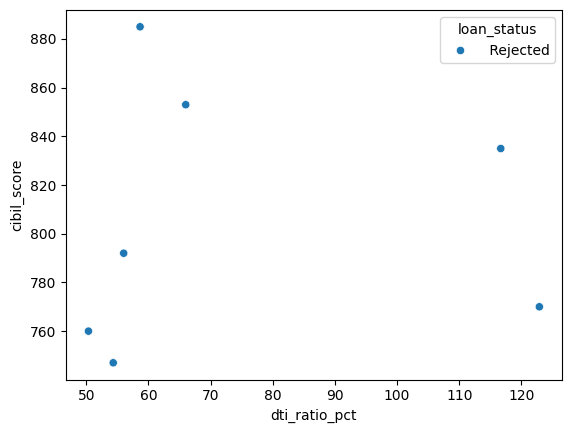

In [ ]:
import seaborn as sns
sns.scatterplot(data = df_highCIBIL, x='dti_ratio_pct', y='cibil_score', hue='loan_status')

**Graph proves that all High CIBIL score loan application were rejected due to high debt-to-income ratio**

Text(0.5, 1.0, 'loan term vs loan status')

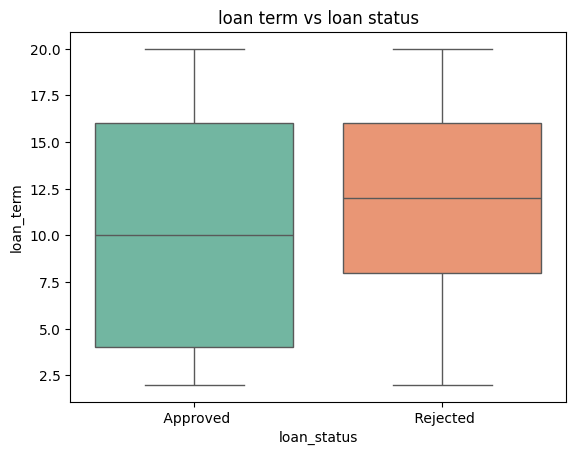

In [ ]:
bp =sns.boxplot(data = df, x='loan_status', y='loan_term', hue='loan_status', palette ='Set2')
plt.title('loan term vs loan status')

In [ ]:
import numpy as np
df.drop(columns=['Status_code'], inplace=True)
df['status_code'] = df['loan_status'].str.strip().map({'Approved': 1, 'Rejected': 0})


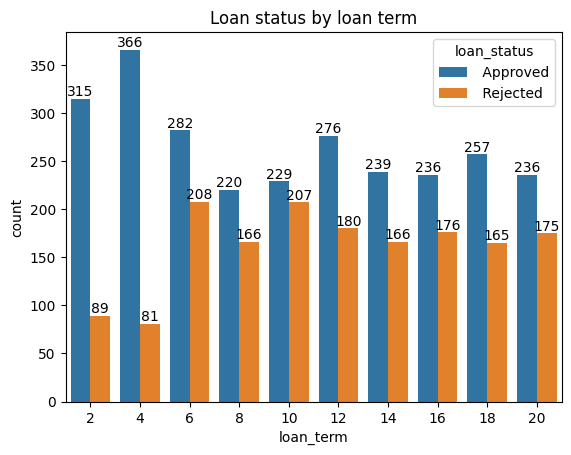

In [ ]:
cp=sns.countplot(data =df, x='loan_term', hue='loan_status')
plt.title('Loan status by loan term')
for bar in cp.containers:
  plt.bar_label(bar)

Lower term loans were highly accpeted and lowly rejected

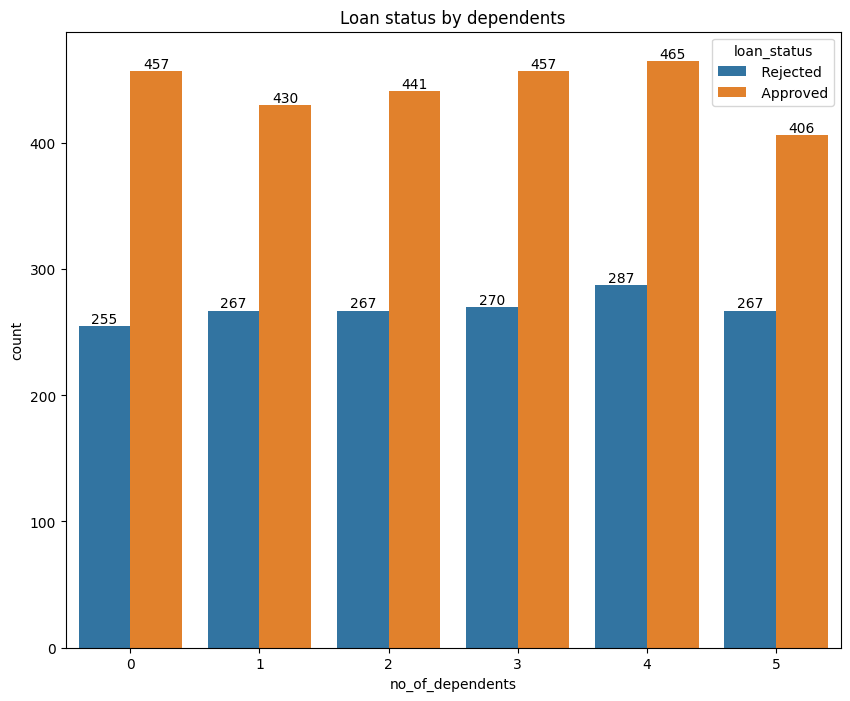

In [ ]:
plt.figure(figsize=(10,8))
plt.title('Loan status by dependents')
cp =sns.countplot(data =df, x='no_of_dependents', hue='loan_status')
for bar in cp.containers:
  plt.bar_label(bar)

Conclusions :



*   Along with High CIBIL score, one should also have low debt-income ratio for the application to be approved.
*   Loans having Shortest Loan term of 2-4 months are most accepted and least rejected.


*   Educated and Non-Educated had similar Approved to Rejected ratio.

